# GlaS Dataset Exploration

Exploratory analysis of the GlaS (Gland Segmentation in Colon Histology Images) dataset: image/mask counts, dimensions, class balance, and representative examples.

**Prerequisite:** run `python scripts/prepare_data.py` first so `data/splits/{train,val,test}.json` exist.

All numbers in this notebook are computed directly from the dataset on disk -- nothing here is hard-coded or estimated.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.data.split import load_split

config = load_config(REPO_ROOT / "configs" / "config.yaml", repo_root=REPO_ROOT)

train_pairs = load_split(config.data.splits_dir / "train.json")
val_pairs = load_split(config.data.splits_dir / "val.json")
test_pairs = load_split(config.data.splits_dir / "test.json")

print(f"train: {len(train_pairs)} | val: {len(val_pairs)} | test: {len(test_pairs)}")
print(f"total official images: {len(train_pairs) + len(val_pairs) + len(test_pairs)}")

train: 68 | val: 17 | test: 80
total official images: 165


## Image and mask dimensions

GlaS images are not all a single fixed resolution. This confirms the actual size distribution and verifies every mask matches its image's dimensions.

In [2]:
all_pairs = train_pairs + val_pairs + test_pairs

records = []
for pair in all_pairs:
    image = cv2.imread(str(pair.image_path), cv2.IMREAD_COLOR)
    mask = cv2.imread(str(pair.mask_path), cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    assert image.shape[:2] == mask.shape[:2], f"mismatch for {pair.image_id}"
    records.append({
        "image_id": pair.image_id,
        "subset": pair.subset,
        "height": image.shape[0],
        "width": image.shape[1],
        "num_instances": int(mask.max()),
    })

df = pd.DataFrame(records)
df.describe()

,height,width,num_instances
count,165.000000,165.000000,165.000000
mean,515.509091,758.739394,9.272727
std,21.550173,53.606959,6.853309
min,430.000000,567.000000,1.000000
25%,522.000000,775.000000,5.000000
50%,522.000000,775.000000,7.000000
75%,522.000000,775.000000,12.000000
max,522.000000,775.000000,32.000000


In [3]:
df.groupby("subset")[["height", "width", "num_instances"]].describe().T

subset                    testA       testB       train
height        count   60.000000   20.000000   85.000000
              mean   511.766667  522.000000  516.623529
              std     26.490399    0.000000   19.812200
              min    433.000000  522.000000  430.000000
              25%    522.000000  522.000000  522.000000
              50%    522.000000  522.000000  522.000000
              75%    522.000000  522.000000  522.000000
              max    522.000000  522.000000  522.000000
width         count   60.000000   20.000000   85.000000
              mean   749.500000  775.000000  761.435294
              std     65.593897    0.000000   49.570644
              min    574.000000  775.000000  567.000000
              25%    775.000000  775.000000  775.000000
              50%    775.000000  775.000000  775.000000
              75%    775.000000  775.000000  775.000000
              max    775.000000  775.000000  775.000000
num_instances count   60.000000   20.000000   85.000000
              mean    11.100000    4.750000    9.047059
              std      7.771526    2.731396    6.346926
              min      1.000000    1.000000    1.000000
              25%      5.750000    2.750000    5.000000
              50%      8.000000    5.500000    7.000000
              75%     14.000000    7.000000   12.000000
              max     32.000000    9.000000   30.000000

## Class distribution: gland vs. background pixel proportion

Computed per-image and in aggregate, on the binarized (semantic) mask.

Overall mean gland pixel fraction: 0.5071
        count      mean       std       min       25%       50%       75%  \
subset                                                                      
testA    60.0  0.493940  0.174874  0.121453  0.374786  0.532317  0.603234   
testB    20.0  0.565639  0.114534  0.359528  0.488668  0.577864  0.623913   
train    85.0  0.502634  0.158924  0.105574  0.401135  0.522144  0.599209   

             max  
subset            
testA   0.858947  
testB   0.796997  
train   0.893514  


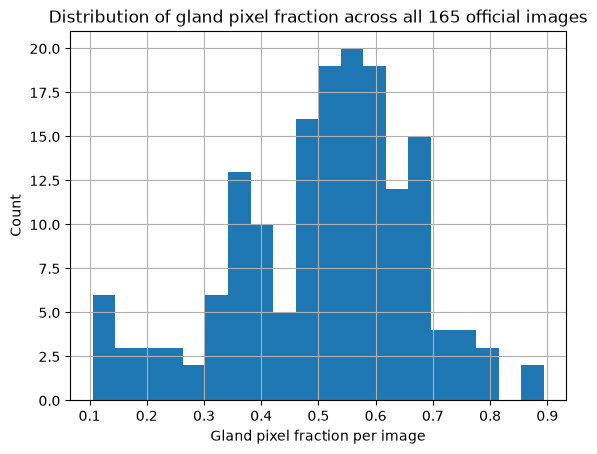

In [4]:
def gland_fraction(pair):
    mask = cv2.imread(str(pair.mask_path), cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    binary = mask > 0
    return binary.mean()

df["gland_fraction"] = [gland_fraction(p) for p in all_pairs]

print(f"Overall mean gland pixel fraction: {df['gland_fraction'].mean():.4f}")
print(df.groupby("subset")["gland_fraction"].describe())

df["gland_fraction"].hist(bins=20)
plt.xlabel("Gland pixel fraction per image")
plt.ylabel("Count")
plt.title("Distribution of gland pixel fraction across all 165 official images")
plt.show()

## Example images, ground-truth masks, and overlays

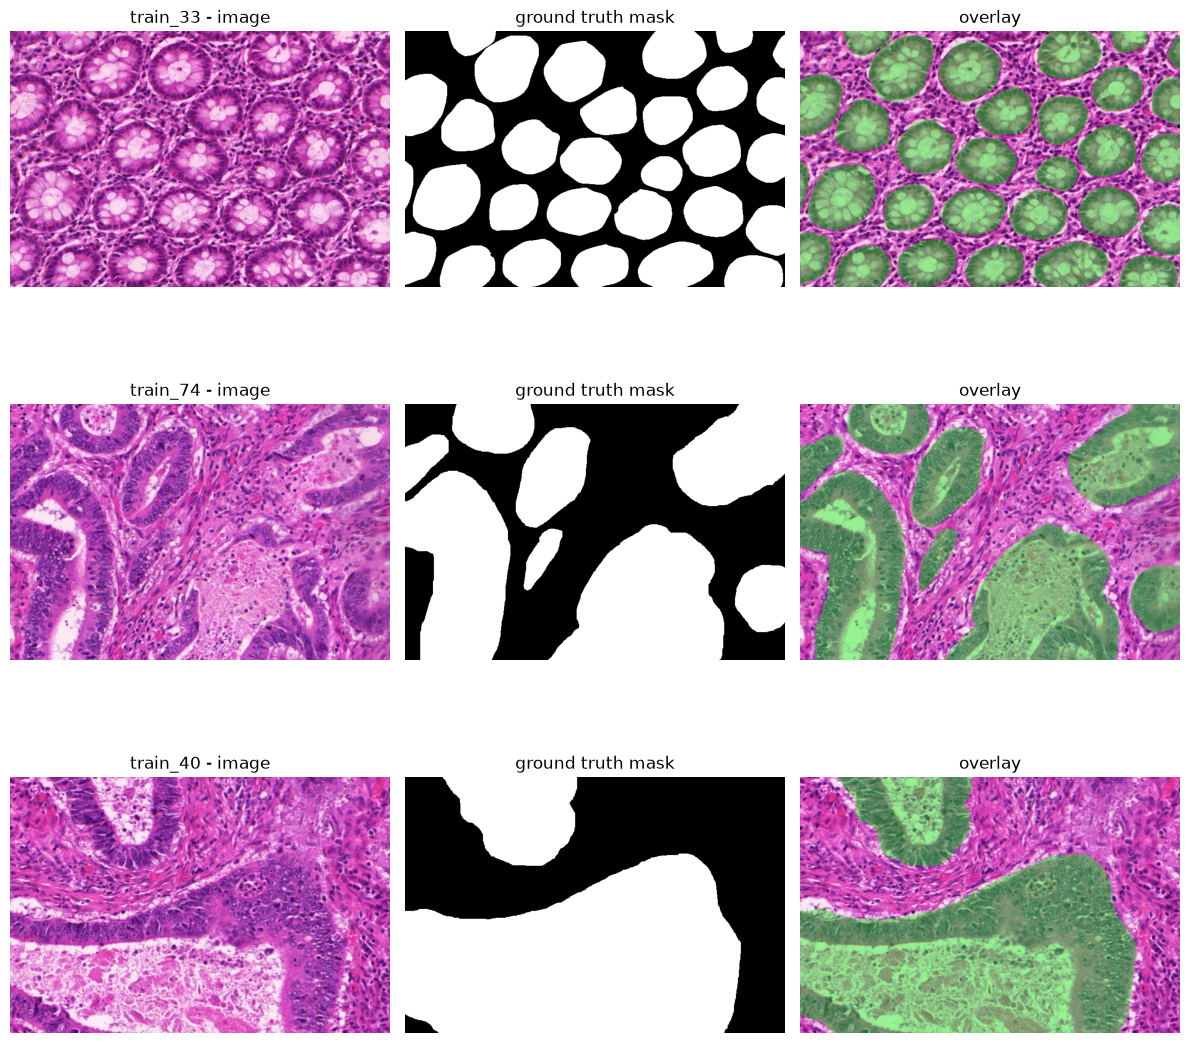

In [5]:
import random
random.seed(0)
sample_pairs = random.sample(train_pairs, k=min(3, len(train_pairs)))

fig, axes = plt.subplots(len(sample_pairs), 3, figsize=(12, 4 * len(sample_pairs)))
if len(sample_pairs) == 1:
    axes = axes[None, :]

for row, pair in enumerate(sample_pairs):
    image = cv2.cvtColor(cv2.imread(str(pair.image_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(pair.mask_path), cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    binary_mask = (mask > 0).astype(np.uint8)

    overlay = image.copy().astype(np.float32) / 255.0
    overlay[binary_mask.astype(bool)] = 0.6 * overlay[binary_mask.astype(bool)] + 0.4 * np.array([0.0, 1.0, 0.0])

    axes[row, 0].imshow(image); axes[row, 0].set_title(f"{pair.image_id} - image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(binary_mask, cmap="gray"); axes[row, 1].set_title("ground truth mask"); axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay); axes[row, 2].set_title("overlay"); axes[row, 2].axis("off")

plt.tight_layout()
plt.show()